# Android Preprocessed Data Analysis

This notebook explores `data/Android_v1/Android_preprocessed_windows.csv`. Each row is a sequential 1,000-line window summarized from Android framework logcat records. The CSV has no labels, so this notebook performs descriptive analysis only; high error/warning rates are not ground-truth anomalies.

## 1. Load and validate the CSV

This cell finds `Android_preprocessed_windows.csv` relative to the workspace, loads its rows, checks that the expected columns exist, and converts feature values to numbers. It also counts empty numeric values and reports how many windows and source lines are present.

**Expected output:** the number of windows and columns, zero or more empty numeric cells, and the first-to-last source line range. With the current file, expect 1,556 windows covering lines 1 through 1,555,005.

**Model connection:** this confirms the number and shape of candidate examples before constructing model inputs. The Android CSV has no class labels, so it cannot train or evaluate a supervised CNN classifier as-is. Its numeric window features can be scaled and explored with DBSCAN, but that would be unsupervised exploration only; it cannot satisfy the assignment's requirement to cluster within a known class or report cluster label composition.

In [1]:
import csv
from datetime import datetime, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

workspace_root = Path.cwd()
while not (workspace_root / "data" / "Android_v1" / "Android_preprocessed_windows.csv").is_file():
    parent = workspace_root.parent
    if parent == workspace_root:
        raise FileNotFoundError("Could not locate data/Android_v1/Android_preprocessed_windows.csv.")
    workspace_root = parent

csv_path = workspace_root / "data" / "Android_v1" / "Android_preprocessed_windows.csv"
with csv_path.open("r", newline="", encoding="utf-8") as input_file:
    reader = csv.DictReader(input_file)
    rows = list(reader)
    columns = reader.fieldnames or []

if not rows:
    raise ValueError(f"No data rows found in {csv_path}")
required_columns = {"line_start", "line_end", "record_count", "malformed_count", "unique_tags", "unique_pids", "tag_entropy_bits", "mean_message_chars", "first_timestamp", "last_timestamp"}
missing_columns = required_columns.difference(columns)
if missing_columns:
    raise ValueError(f"CSV is missing expected columns: {sorted(missing_columns)}")

text_columns = {"first_timestamp", "last_timestamp"}
numeric_columns = [column for column in columns if column not in text_columns]
empty_cells = 0
for row in rows:
    for column in numeric_columns:
        value = row[column]
        if value == "":
            row[column] = float("nan")
            empty_cells += 1
        else:
            row[column] = float(value)

print(f"Loaded {len(rows):,} windows from {csv_path.relative_to(workspace_root)}")
print(f"Columns: {len(columns)}; empty numeric cells: {empty_cells}")
print(f"Input lines covered: {int(rows[0]['line_start']):,} to {int(rows[-1]['line_end']):,}")

Loaded 1,556 windows from data\Android_v1\Android_preprocessed_windows.csv
Columns: 36; empty numeric cells: 0
Input lines covered: 1 to 1,555,005


## 2. Check data quality and summarize features

This cell checks whether the windows cover contiguous source lines and whether the six severity rates add up to approximately 100% per window. It reports totals and descriptive statistics (mean, median, minimum, maximum) for each core feature, then estimates the overall share of records represented by the stored common-tag columns.

**Expected output:** counts for windows, parsed records, malformed lines, and any gaps; a true/false severity-rate check; one summary line per feature; and the most common stored tags with their estimated shares. The current file has no gaps, 64 malformed lines, and valid severity-rate totals. Feature/rate summaries are descriptive, not labels.

**Model connection:** these ranges help plan feature scaling and identify low-variance, incomplete, or highly imbalanced inputs before modeling. CNN classification still needs reliable labels and separate labeled log sources. For DBSCAN, scaling matters because distance-based neighborhoods can otherwise be dominated by large-count columns; the output also confirms these are sequential windows from one file, not independent labeled classes.

In [2]:
record_counts = np.asarray([row["record_count"] for row in rows])
malformed_counts = np.asarray([row["malformed_count"] for row in rows])
line_gaps = [
    index for index in range(1, len(rows))
    if int(rows[index]["line_start"]) != int(rows[index - 1]["line_end"]) + 1
]
severity_names = ["verbose", "debug", "info", "warning", "error", "fatal"]
severity_columns = [f"level_{name}_rate" for name in severity_names]
severity_sums = np.asarray([sum(row[column] for column in severity_columns) for row in rows])

print(f"Windows: {len(rows):,}")
print(f"Parsed records: {int(record_counts.sum()):,}")
print(f"Malformed lines: {int(malformed_counts.sum()):,}")
print(f"Non-contiguous window boundaries: {len(line_gaps)}")
print(f"Severity rates sum to 1 within tolerance for all windows: {np.allclose(severity_sums, 1.0, atol=0.002)}")
print("\nNumeric feature summary (mean / median / min / max):")
summary_columns = ["record_count", "malformed_count", "unique_tags", "unique_pids", "tag_entropy_bits", "mean_message_chars", *severity_columns]
for column in summary_columns:
    values = np.asarray([row[column] for row in rows], dtype=float)
    print(f"{column}: {values.mean():.4f} / {np.median(values):.4f} / {values.min():.4f} / {values.max():.4f}")

tag_columns = [column for column in columns if column.startswith("tag_rate:")]
weighted_tag_counts = {
    column.removeprefix("tag_rate:"): sum(row[column] * row["record_count"] for row in rows)
    for column in tag_columns
}
total_records = record_counts.sum() or 1
print("\nTop stored tags by estimated record share:")
for tag, count in sorted(weighted_tag_counts.items(), key=lambda item: item[1], reverse=True)[:15]:
    print(f"{tag}: {count / total_records:.2%}")

Windows: 1,556
Parsed records: 1,554,941
Malformed lines: 64
Non-contiguous window boundaries: 0
Severity rates sum to 1 within tolerance for all windows: True

Numeric feature summary (mean / median / min / max):
record_count: 999.3194 / 1000.0000 / 5.0000 / 1000.0000
malformed_count: 0.0411 / 0.0000 / 0.0000 / 16.0000
unique_tags: 105.9422 / 97.0000 / 3.0000 / 213.0000
unique_pids: 18.3233 / 17.0000 / 2.0000 / 35.0000
tag_entropy_bits: 5.0500 / 5.2060 / 0.0409 / 6.8699
mean_message_chars: 70.3298 / 70.8710 / 20.1630 / 193.6130
level_verbose_rate: 0.0285 / 0.0200 / 0.0000 / 0.3900
level_debug_rate: 0.3252 / 0.3200 / 0.0030 / 0.9150
level_info_rate: 0.4927 / 0.4720 / 0.0480 / 0.9790
level_warning_rate: 0.0520 / 0.0470 / 0.0000 / 0.2640
level_error_rate: 0.1014 / 0.0810 / 0.0000 / 0.9110
level_fatal_rate: 0.0001 / 0.0000 / 0.0000 / 0.0710

Top stored tags by estimated record share:
SDK: 8.59%
PowerManagerService: 4.88%
HwCustMobileSignalControllerImpl: 3.58%
wpa_supplicant: 3.43%
HwSign

## 3. Visualize changes across the log

This cell plots record counts, tag entropy, warning/error/fatal rates, and rates for the eight most common tags across sequential windows. A second chart compares the overall estimated shares of the most common stored tags.

**Expected output:** a four-panel timeline plus a tag-share bar chart. Peaks or shifts show where the log's volume, message severity, or tag mix changes over file order. They are candidates for checking against the raw log, not proof of an incident.

**Model connection:** changes over window order can suggest which measurements a future CNN should receive and whether it should use neighboring windows as a sequence. However, these rows contain aggregated rates and discard the order of events inside each 1,000-line window. They support a feature-vector baseline, not a true syscall/token-sequence CNN. A DBSCAN experiment could group scaled windows with similar summaries, but without labels it cannot be interpreted as within-class clustering.

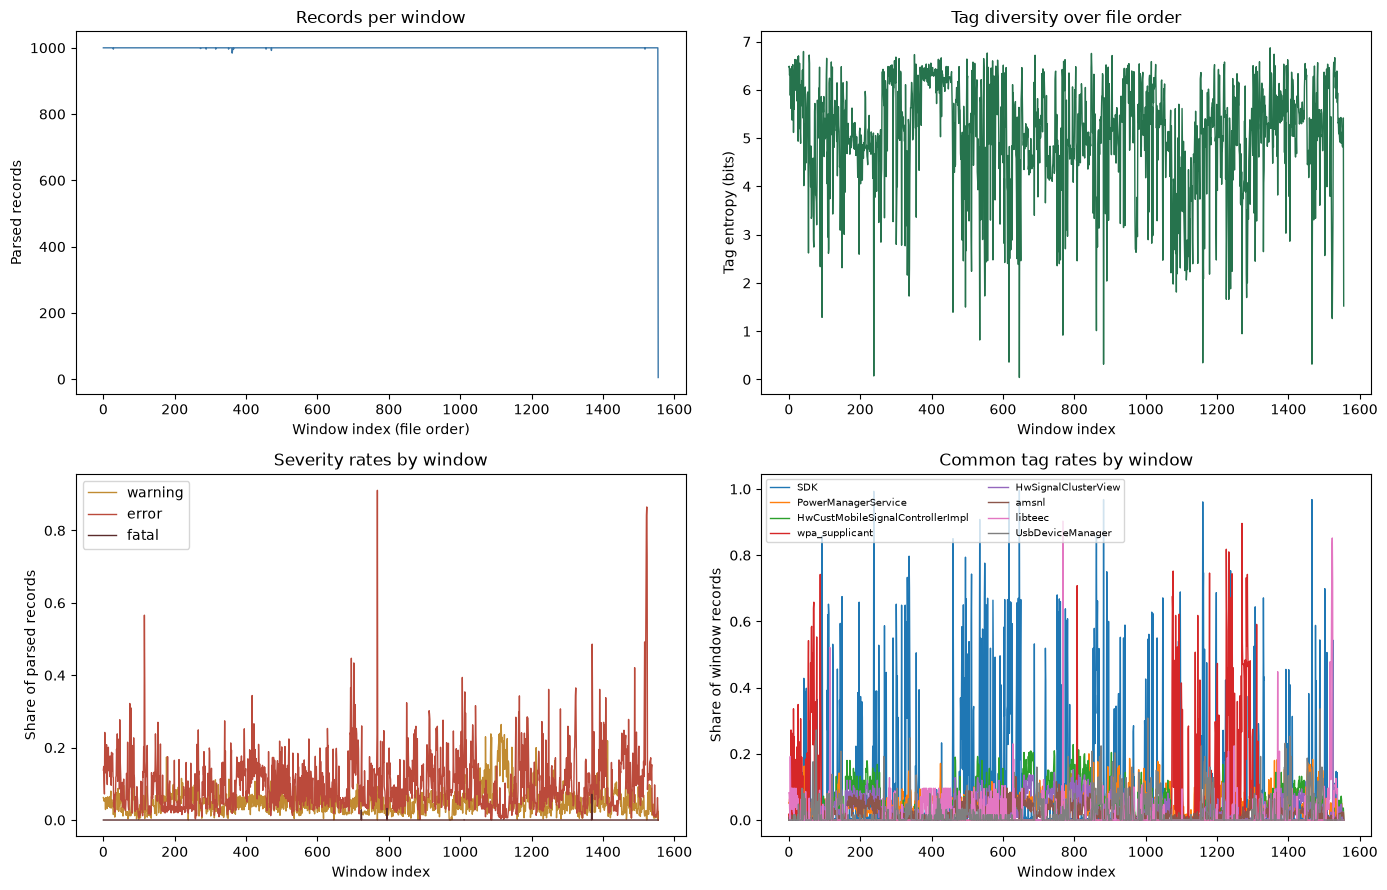

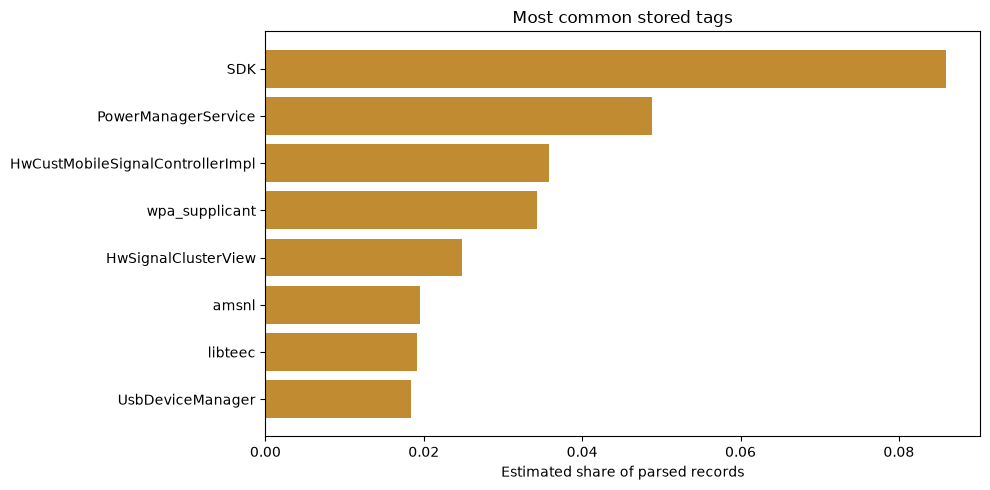

In [3]:
window_index = np.arange(len(rows))
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(window_index, record_counts, color="#3976a8", linewidth=1)
axes[0, 0].set(title="Records per window", xlabel="Window index (file order)", ylabel="Parsed records")
axes[0, 1].plot(window_index, [row["tag_entropy_bits"] for row in rows], color="#26734d", linewidth=1)
axes[0, 1].set(title="Tag diversity over file order", xlabel="Window index", ylabel="Tag entropy (bits)")
axes[1, 0].plot(window_index, [row["level_warning_rate"] for row in rows], label="warning", color="#c18b32", linewidth=1)
axes[1, 0].plot(window_index, [row["level_error_rate"] for row in rows], label="error", color="#bb4a3b", linewidth=1)
axes[1, 0].plot(window_index, [row["level_fatal_rate"] for row in rows], label="fatal", color="#5b2c2c", linewidth=1)
axes[1, 0].set(title="Severity rates by window", xlabel="Window index", ylabel="Share of parsed records")
axes[1, 0].legend()
top_tags = sorted(weighted_tag_counts, key=weighted_tag_counts.get, reverse=True)[:8]
for tag in top_tags:
    tag_column = f"tag_rate:{tag}"
    axes[1, 1].plot(window_index, [row[tag_column] for row in rows], linewidth=1, label=tag)
axes[1, 1].set(title="Common tag rates by window", xlabel="Window index", ylabel="Share of window records")
axes[1, 1].legend(fontsize=7, ncol=2)
fig.tight_layout()
plt.show()

top_tag_names = top_tags[:12]
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_tag_names[::-1], [weighted_tag_counts[tag] / total_records for tag in top_tag_names[::-1]], color="#c18b32")
ax.set(title="Most common stored tags", xlabel="Estimated share of parsed records")
fig.tight_layout()
plt.show()

## 4. Compare feature relationships

This cell calculates Pearson correlations among record volume, tag/process diversity, entropy, message length, and severe-message rates. The heatmap shows the direction and strength of pairwise linear relationships; the printed list ranks the strongest ones.

**Expected output:** a correlation heatmap with values from -1 to 1 and a short ranked list. Positive values mean two features tend to rise together; negative values mean one tends to fall as the other rises. Correlation is descriptive and does not show that one feature causes another.

**Model connection:** strongly correlated channels may be redundant. This can guide a simpler CNN feature set and help reduce noisy dimensions before clustering. DBSCAN uses distances, so redundant or unscaled features can distort neighborhoods; check these relationships before selecting and scaling its inputs. Correlation analysis does not provide labels or prove predictive usefulness.

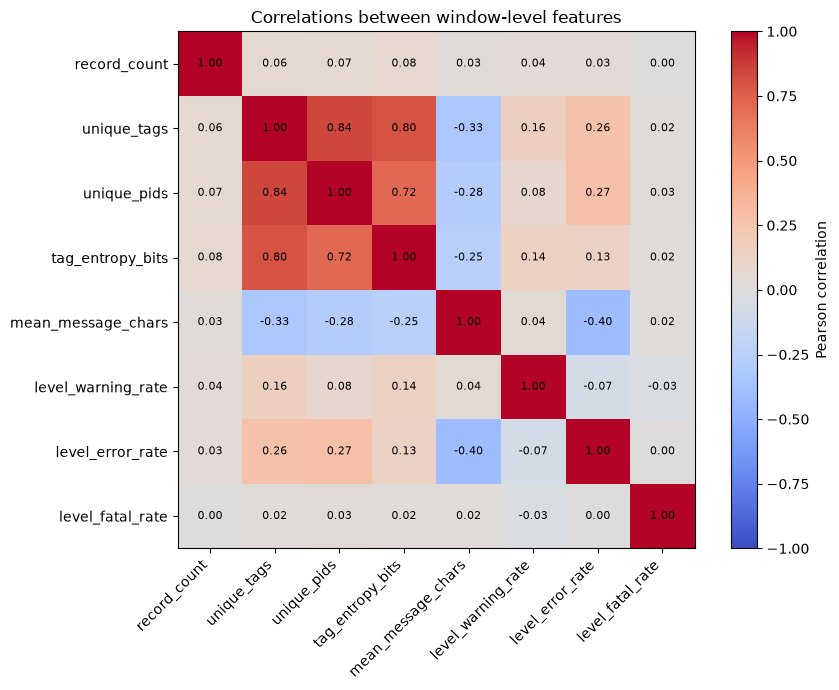

Strongest absolute feature relationships (excluding self-correlation):
unique_tags vs unique_pids: r=0.839
unique_tags vs tag_entropy_bits: r=0.803
unique_pids vs tag_entropy_bits: r=0.715
mean_message_chars vs level_error_rate: r=-0.403
unique_tags vs mean_message_chars: r=-0.325
unique_pids vs mean_message_chars: r=-0.281
unique_pids vs level_error_rate: r=0.274
unique_tags vs level_error_rate: r=0.265


In [4]:
correlation_features = ["record_count", "unique_tags", "unique_pids", "tag_entropy_bits", "mean_message_chars", "level_warning_rate", "level_error_rate", "level_fatal_rate"]
correlation_matrix = np.asarray([[row[name] for name in correlation_features] for row in rows], dtype=float)
correlations = np.corrcoef(correlation_matrix, rowvar=False)

fig, ax = plt.subplots(figsize=(9, 7))
image = ax.imshow(correlations, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(correlation_features)), correlation_features, rotation=45, ha="right")
ax.set_yticks(range(len(correlation_features)), correlation_features)
ax.set_title("Correlations between window-level features")
for row_index in range(len(correlation_features)):
    for column_index in range(len(correlation_features)):
        ax.text(column_index, row_index, f"{correlations[row_index, column_index]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=ax, label="Pearson correlation")
fig.tight_layout()
plt.show()

print("Strongest absolute feature relationships (excluding self-correlation):")
relationships = []
for left in range(len(correlation_features)):
    for right in range(left + 1, len(correlation_features)):
        relationships.append((abs(correlations[left, right]), correlation_features[left], correlation_features[right], correlations[left, right]))
for _, left_name, right_name, coefficient in sorted(relationships, reverse=True)[:8]:
    print(f"{left_name} vs {right_name}: r={coefficient:.3f}")

## 5. Review windows with the highest error rates

This cell selects the ten windows with the largest fraction of error-level records and prints their source line ranges, timestamps, warning rate, tag entropy, and strongest stored tags.

**Expected output:** ten compact dictionaries that help you locate interesting portions of the original Android log. Open those line ranges in `Android.log` before drawing conclusions. A high error rate only describes log severity; this dataset has no labels to say whether a window is malicious or abnormal.

**Model connection:** this review can help a human annotate candidate windows before building a labeled CNN classifier, but annotations need domain validation and must be split by source/time before training. These records are not false positives or negatives because no ground-truth labels exist. They also cannot provide DBSCAN cluster composition until trustworthy labels are added; for DBSCAN they are only examples to inspect after fitting.

In [5]:
# Inspect windows with the highest error rates. These are review candidates, not labeled anomalies.
review_order = sorted(range(len(rows)), key=lambda index: rows[index]["level_error_rate"], reverse=True)[:10]
print("Highest error-rate windows (inspect the corresponding raw log lines before interpreting):")
for index in review_order:
    row = rows[index]
    dominant_tags = sorted(
        ((tag, row[f"tag_rate:{tag}"]) for tag in top_tags),
        key=lambda item: item[1],
        reverse=True,
    )[:3]
    print({
        "window_index": index,
        "source_lines": f"{int(row['line_start'])}-{int(row['line_end'])}",
        "timestamps": f"{row['first_timestamp']} to {row['last_timestamp']}",
        "error_rate": round(row["level_error_rate"], 3),
        "warning_rate": round(row["level_warning_rate"], 3),
        "tag_entropy_bits": round(row["tag_entropy_bits"], 3),
        "dominant_stored_tags": dominant_tags,
    })

Highest error-rate windows (inspect the corresponding raw log lines before interpreting):
{'window_index': 768, 'source_lines': '768001-769000', 'timestamps': '12-18 07:57:05.615 to 12-18 07:57:06.469', 'error_rate': 0.911, 'warning_rate': 0.0, 'tag_entropy_bits': 0.918, 'dominant_stored_tags': [('libteec', 0.903), ('amsnl', 0.004), ('SDK', 0.0)]}
{'window_index': 1523, 'source_lines': '1523001-1524000', 'timestamps': '12-18 19:49:56.724 to 12-18 19:49:57.462', 'error_rate': 0.865, 'warning_rate': 0.0, 'tag_entropy_bits': 1.262, 'dominant_stored_tags': [('libteec', 0.852), ('amsnl', 0.004), ('SDK', 0.002)]}
{'window_index': 1522, 'source_lines': '1522001-1523000', 'timestamps': '12-18 19:49:56.000 to 12-18 19:49:56.723', 'error_rate': 0.842, 'warning_rate': 0.006, 'tag_entropy_bits': 1.344, 'dominant_stored_tags': [('libteec', 0.825), ('HwCustMobileSignalControllerImpl', 0.012), ('HwSignalClusterView', 0.008)]}
{'window_index': 1524, 'source_lines': '1524001-1525000', 'timestamps': '12

## Interpretation Notes

The rows are ordered windows from one log file, not independent devices or labeled events. Trends may reflect changing workload and file order. Tag-rate columns cover only the globally common tags retained by preprocessing, so their rates do not sum to 1. Correlation indicates association, not cause. Error/fatal log severity describes the message's severity, not whether the activity is malicious. Use the raw source lines around a flagged window for manual investigation; this CSV alone cannot support classification metrics or anomaly ground truth.